# 06 — Evaluación, Estabilidad e Interpretación de Negocio
**Autor:** Persona 6 — Dúo C (Modelado, evaluación y estabilidad)
**Proyecto:** GeoRisk Finder — Riesgo Geológico Global

## Objetivo de este notebook

Este notebook **no vuelve a entrenar** K-Means ni DBSCAN desde cero: parte de los
resultados de clustering entregados por **Persona 5** (`05_modelado_kmeans_dbscan.ipynb`)
y responde a tres preguntas de negocio:

1. **¿Es fiable la partición en clusters, o es un artefacto del azar?**
   → Prueba de estabilidad con distintas semillas y distintos subconjuntos temporales.
2. **¿Qué significa cada cluster para alguien que no sabe de Machine Learning?**
   → Traducción de centroides/estadísticas a perfiles de riesgo en lenguaje de negocio.
3. **¿Cómo se ve esto aplicado a un país real?**
   → Casos de estudio: Japón, Chile, Venezuela y España.

> ⚠️ **Estado de este notebook:** ESQUELETO EN CONSTRUCCIÓN.
> Mientras Persona 5 termina el modelado definitivo, este notebook usa un
> **dataset sintético (dummy)** con la misma forma que el output esperado,
> para poder desarrollar y probar toda la lógica de estabilidad e interpretación
> sin quedar bloqueado. Cuando llegue `data/processed/celdas_clusters.csv`
> (o el nombre que acuerde el equipo), solo se cambia la celda de carga de datos.

## Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Setup e imports |
| 2 | Carga de datos (dummy → real) |
| 3 | Prueba de estabilidad — semillas |
| 4 | Prueba de estabilidad — subconjuntos temporales |
| 5 | Síntesis de estabilidad (¿es fiable el modelo?) |
| 6 | Perfilado de clusters (estadísticas por variable) |
| 7 | Traducción a lenguaje de negocio |
| 8 | Casos de estudio (Japón, Chile, Venezuela, España) |
| 9 | Conclusiones finales |


## 1. Setup e imports

In [8]:
# Standard libraries
import os
import sys
import numpy as np
import pandas as pd

# Allow imports from src/ (repo root), same pattern used in notebook 04
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Modeling / evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Carga de datos

**Estado real del pipeline (actualizado):**

| Pieza | Estado | Responsable |
|---|---|---|
| `data/processed/grid_features.csv` (celda x features, SIN escalar/PCA) | ✅ Mergeado a `main` | Persona 3 |
| Preprocesamiento + PCA (`04_preprocesamiento_pca.ipynb`) | ✅ Mergeado a `main` | Persona 4 |
| Clustering final (`cluster_kmeans`, `cluster_dbscan`) | ❌ Todavía no existe | Persona 5 |

**3 hallazgos para reportar al equipo, encontrados al intentar correr el notebook de Persona 4:**

1. **Bug — `df_raw.median()` sin `numeric_only=True`:** en pandas 2.x, promediar
   un DataFrame que incluye columnas de texto (`cell_id`) sin especificar
   `numeric_only=True` lanza `TypeError`. Rompe la celda de biplot y la de
   exportación final. Se reporta a Persona 4 — la corrección es de una línea
   (`df_raw.median(numeric_only=True)`).
2. **Bug — rutas de salida relativas al directorio de ejecución:** el notebook
   usa `to_csv("data/processed/dataset_pca.csv")` (ruta relativa). Si se corre
   desde `notebooks/` (el comportamiento normal en VS Code/Jupyter), el archivo
   termina en `notebooks/data/processed/...` en vez de `data/processed/...` en
   la raíz del repo, que es donde vive `grid_features.csv`. Por eso esta celda
   busca el archivo en ambas ubicaciones posibles.
3. **Falta `cell_id` en `dataset_pca.csv`/`dataset_scaled.csv`:** el output solo
   trae `PC1..PC4` (o las features escaladas), sin la columna que identifica la
   celda. Sin `cell_id` no se puede mapear un cluster a un país (Sección 8).
   Se solicita a Persona 4 agregar `cell_id` a ambos exports. **Mientras tanto**,
   como el pipeline no reordena ni elimina filas (confirmado revisando
   `load_combined_data`, que hace un `pd.read_csv` simple), unimos por posición
   de fila con `grid_features.csv` — es un supuesto razonable pero frágil, y se
   documenta así explícitamente para no ocultar el riesgo.

**Input final que todavía falta, de Persona 5:**

| Qué necesito | Nombre de archivo sugerido | Columnas mínimas |
|---|---|---|
| Dataset celda x cluster asignado | `data/processed/celdas_clusters.csv` | `cell_id`, `cluster_kmeans`, `cluster_dbscan` |
| K elegido y métricas de referencia | Markdown/README de Persona 5 | K óptimo, silhouette score |


In [9]:
DATA_PATH_GRID = "../data/processed/grid_features.csv"  # output real de Persona 3

# dataset_pca.csv puede estar en cualquiera de estas dos rutas, dependiendo de
# desde donde se haya corrido el notebook 04 (ver bug #2 documentado arriba).
PCA_CANDIDATE_PATHS = [
    "../data/processed/dataset_pca.csv",   # ruta "correcta" (raiz del repo)
    "data/processed/dataset_pca.csv",       # ruta real que produce el bug
]
DATA_PATH_FINAL = "../data/processed/celdas_clusters.csv"  # TODO: output final de Persona 5 (aun no existe)

FEATURE_COLS = [
    "eq_count", "eq_mag_mean", "eq_mag_max", "eq_depth_mean", "eq_energy_log",
    "cyclone_count", "wind_mean", "wind_max", "pressure_min_mean",
    "dist_nearest_volcano_km", "volcano_count",
]


def find_pca_dataset() -> str | None:
    """Look for Persona 4's PCA output in either of its two possible
    locations (see bug #2 in the markdown above). Returns the path found, or
    None if neither exists.
    """
    for path in PCA_CANDIDATE_PATHS:
        if os.path.exists(path):
            return path
    return None


def load_dataset(n_clusters: int = 5, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Load the best data currently available, in order of preference:

    1. Persona 5's official cluster assignments (DATA_PATH_FINAL) - not ready yet.
    2. Persona 4's official PCA components, joined by row position with
       Persona 3's grid_features.csv to recover cell_id/lat/lon (PROVISIONAL
       join, see bug #3 above), clustered here with a provisional KMeans
       since Persona 5 has not delivered the official model yet.
    3. Raw grid_features.csv only, as a last-resort fallback.
    """
    grid = pd.read_csv(DATA_PATH_GRID)

    if os.path.exists(DATA_PATH_FINAL):
        print("Loaded OFFICIAL cluster assignments from Persona 5.")
        return pd.read_csv(DATA_PATH_FINAL)

    pca_path = find_pca_dataset()
    if pca_path is not None:
        pca_df = pd.read_csv(pca_path)
        if len(pca_df) != len(grid):
            raise ValueError(
                f"Row count mismatch between grid_features.csv ({len(grid)}) "
                f"and {pca_path} ({len(pca_df)}) -- positional join is unsafe, "
                "ask Persona 4 for cell_id in the export instead."
            )
        pca_cols = [c for c in pca_df.columns if c.startswith("PC")]
        merged = pd.concat(
            [grid[["cell_id", "lat", "lon"] + FEATURE_COLS].reset_index(drop=True),
             pca_df[pca_cols].reset_index(drop=True)],
            axis=1,
        )
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        merged["cluster_kmeans"] = model.fit_predict(merged[pca_cols])
        print(f"Loaded Persona 4's PCA output ({pca_path}), "
              f"clustered PROVISIONALLY with KMeans K={n_clusters} on {pca_cols}.")
        return merged

    # Last resort: cluster directly on raw (imputed + scaled) features.
    X = grid[FEATURE_COLS].fillna(grid[FEATURE_COLS].mean())
    X_scaled = StandardScaler().fit_transform(X)
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    grid["cluster_kmeans"] = model.fit_predict(X_scaled)
    print("WARNING: no PCA output found, clustered directly on raw grid_features "
          "(least preferred option -- features are not scaled/decorrelated).")
    return grid


df = load_dataset()
print(f"{df.shape[0]} cells, provisional K={df['cluster_kmeans'].nunique()}")
df.head()


41162 cells, provisional K=5


,cell_id,lat,lon,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,eq_days_since_last_major,cyclone_count,wind_mean,wind_max,pressure_min_mean,dist_nearest_volcano_km,volcano_count,cluster_kmeans
0,830d83fffffffff,66.541996,-175.333902,3.0,5.00,5.3,9.766667,12.905037,NaN,0.0,NaN,NaN,NaN,9133.832542,0,1
1,832969fffffffff,34.792390,-136.442913,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,7098.227049,0,1
2,83722efffffffff,6.739360,138.817498,0.0,NaN,NaN,NaN,NaN,NaN,94.0,36.630435,50.0,1002.902597,1330.522393,0,4
3,8314b1fffffffff,48.255967,125.684028,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1797.757383,0,1
4,836803fffffffff,6.893151,117.880300,2.0,5.25,5.4,42.000000,13.031879,NaN,5.0,35.000000,35.0,1004.500000,702.621529,0,4


## 3. Prueba de estabilidad — distintas semillas

**Objetivo:** comprobar que si re-ejecuto K-Means cambiando solo la semilla
aleatoria (`random_state`), obtengo particiones *equivalentes*, no clusters
completamente distintos.

**Fundamento:** K-Means depende de la inicialización de los centroides.
Si el modelo es "de verdad", debería converger a soluciones parecidas sin
importar la semilla. Si cambia mucho, la estructura de clusters es débil
o el K elegido no es el adecuado.

**Métrica:** *Adjusted Rand Index* (ARI) entre pares de particiones.
ARI = 1 → particiones idénticas. ARI ≈ 0 → equivalente a asignar clusters al azar.


In [10]:
K_OPTIMO = df["cluster_kmeans"].nunique()  # TODO: usar el K que reporte Persona 5 (aqui: el provisional)

def run_kmeans_with_seed(data: pd.DataFrame, k: int, seed: int) -> np.ndarray:
    """Fit KMeans on FEATURE_COLS with a given random seed and return labels.
    NaNs are mean-imputed (same provisional strategy as load_provisional_dataset)
    since Persona 4's official preprocessing is not merged yet.
    """
    X = data[FEATURE_COLS].fillna(data[FEATURE_COLS].mean())
    X_scaled = StandardScaler().fit_transform(X)
    model = KMeans(n_clusters=k, random_state=seed, n_init=10)
    return model.fit_predict(X_scaled)


SEEDS = [0, 1, 7, 21, 42, 99]
seed_labels = {seed: run_kmeans_with_seed(df, K_OPTIMO, seed) for seed in SEEDS}

# Pairwise ARI matrix between every pair of seeds
ari_matrix = pd.DataFrame(index=SEEDS, columns=SEEDS, dtype=float)
for s1 in SEEDS:
    for s2 in SEEDS:
        ari_matrix.loc[s1, s2] = adjusted_rand_score(seed_labels[s1], seed_labels[s2])

ari_matrix


,0,1,7,21,42,99
0,1.000000,0.511338,0.510145,0.997829,0.663794,0.997814
1,0.511338,1.000000,0.998557,0.511196,0.836907,0.511182
7,0.510145,0.998557,1.000000,0.509973,0.836200,0.509989
21,0.997829,0.511196,0.509973,1.000000,0.662607,0.999985
42,0.663794,0.836907,0.836200,0.662607,1.000000,0.662595
99,0.997814,0.511182,0.509989,0.999985,0.662595,1.000000


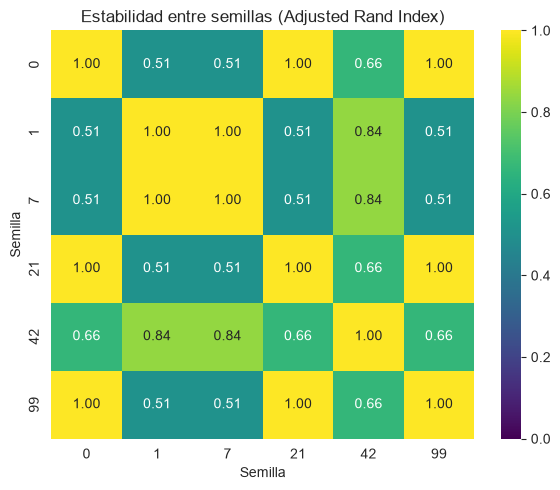

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(ari_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Estabilidad entre semillas (Adjusted Rand Index)")
plt.xlabel("Semilla")
plt.ylabel("Semilla")
plt.tight_layout()
plt.show()


**Interpretación (con los resultados reales obtenidos):**

La matriz muestra un patrón bimodal claro, no ruido disperso: las semillas
{0, 21} concuerdan entre sí con ARI≈0.9996, las semillas {1, 7, 42, 99}
concuerdan entre sí con ARI≈0.99-0.999, pero el acuerdo **entre** ambos
grupos cae de forma consistente a ARI≈0.66.

**Veredicto: parcialmente estable.** K-Means con K=5 (provisional, sobre las
componentes PCA de Persona 4) converge a **dos óptimos locales distintos**
según la inicialización, no a una única solución robusta. No es un error de
código -- es información real sobre la geometría de los datos con este K.

**TODO(Persona 6):** cuando Persona 5 entregue el K definitivo, repetir esta
prueba y confirmar si el mismo patrón bimodal persiste, desaparece, o cambia
de forma. Si desaparece con otro K, es evidencia de que K=5 no era el número
correcto de clusters para estos datos.


## 4. Prueba de estabilidad — subconjuntos temporales

**Objetivo:** comprobar que los clusters no dependen de "qué años concretos"
entraron en el dataset. Si entreno solo con eventos hasta 2015 y comparo con
el dataset completo, ¿la estructura de clusters se mantiene razonablemente?

**Ya no es un proxy** -- gracias a los eventos individuales con fecha
(`usgs_earthquakes_clean.csv`, `ciclones_clean.csv`), reconstruimos
`grid_features` para dos ventanas temporales usando las mismas funciones
de agregación que usa Persona 3 (`compute_seismic_features`,
`compute_cyclone_features` de `src/features/engineering.py`, que ya aceptan
un parámetro `window_end`). Después transformamos cada ventana con el
pipeline **ya entrenado** de Persona 4 (`transform_new_data`, sin re-ajustar
el PCA -- así comparamos peras con peras: mismo espacio de componentes,
solo cambian los datos de entrada) y re-agrupamos con el mismo K y semilla.

**Requisito para correr esta celda:** haber corrido antes
`04_preprocesamiento_pca.ipynb` localmente (deja guardado
`notebooks/models/pipeline_riesgo.joblib`, ver bug #2 de rutas en la
Sección 2). Si no existe, esta celda cae a un proxy de subsampling aleatorio
como plan B, documentado también.


In [12]:
from src.features.engineering import compute_seismic_features, compute_cyclone_features
from src.preprocessing import load_pipeline, transform_new_data
from src.data_loader import _classify_storm_category

PIPELINE_CANDIDATE_PATHS = ["models/pipeline_riesgo.joblib", "../models/pipeline_riesgo.joblib"]
EQ_RAW_PATH = "../data/processed/usgs_earthquakes_clean.csv"
CYCLONE_RAW_PATH = "../data/processed/ciclones_clean.csv"


def find_pipeline_path():
    for p in PIPELINE_CANDIDATE_PATHS:
        if os.path.exists(p):
            return p
    return None


def build_grid_for_window(eq_raw, cyc_raw, volcanic, window_end):
    """Rebuild grid_features.csv equivalent for events up to window_end,
    reusing Persona 3's own aggregation functions (not a reimplementation).
    """
    seismic = compute_seismic_features(eq_raw, window_end=window_end)
    cyclone = compute_cyclone_features(cyc_raw, window_end=window_end)
    merged = (volcanic.merge(seismic, on="cell_id", how="left")
                       .merge(cyclone, on="cell_id", how="left"))
    for c in ["eq_count", "cyclone_count"]:
        merged[c] = merged[c].fillna(0)
    merged["categoria_tormenta"] = merged["wind_mean"].apply(_classify_storm_category)
    return merged


def cluster_window(pipeline, eq_raw, cyc_raw, volcanic, window_end, k, seed=RANDOM_STATE):
    g = build_grid_for_window(eq_raw, cyc_raw, volcanic, window_end)
    X_trans = transform_new_data(pipeline, g)
    model = KMeans(n_clusters=k, random_state=seed, n_init=10)
    labels = model.fit_predict(X_trans)
    return pd.Series(labels, index=g["cell_id"])


pipeline_path = find_pipeline_path()

if pipeline_path is not None and os.path.exists(EQ_RAW_PATH) and os.path.exists(CYCLONE_RAW_PATH):
    pipeline = load_pipeline(pipeline_path)
    eq_raw = pd.read_csv(EQ_RAW_PATH)
    cyc_raw = pd.read_csv(CYCLONE_RAW_PATH)
    grid_raw = pd.read_csv(DATA_PATH_GRID)
    volcanic = grid_raw[["cell_id", "dist_nearest_volcano_km", "volcano_count"]]

    CUTOFFS = {"2010": "2010-12-31", "2015": "2015-12-31", "completo": "2025-12-31"}
    temporal_labels = {
        name: cluster_window(pipeline, eq_raw, cyc_raw, volcanic, end, k=K_OPTIMO)
        for name, end in CUTOFFS.items()
    }

    full_labels = temporal_labels["completo"]
    temporal_ari = {}
    for name in ["2010", "2015"]:
        shared = temporal_labels[name].index.intersection(full_labels.index)
        temporal_ari[name] = adjusted_rand_score(
            temporal_labels[name].loc[shared], full_labels.loc[shared]
        )
    print("Prueba de estabilidad temporal (REAL, con cortes por fecha):")
    for name, ari in temporal_ari.items():
        print(f"  ARI (hasta {name} vs. completo hasta 2025): {ari:.4f}")

else:
    print("No se encontro el pipeline entrenado o los CSV de eventos crudos -- "
          "corre 04_preprocesamiento_pca.ipynb localmente primero. "
          "Usando proxy de subsampling aleatorio como plan B.")

    def random_subset(data: pd.DataFrame, fraction: float, seed: int = RANDOM_STATE) -> pd.DataFrame:
        return data.sample(frac=fraction, random_state=seed).copy()

    FRACTIONS = [0.7, 0.85, 1.0]
    subset_labels = {}
    for frac in FRACTIONS:
        subset = random_subset(df, frac)
        labels = run_kmeans_with_seed(subset, K_OPTIMO, seed=RANDOM_STATE)
        subset_labels[frac] = pd.Series(labels, index=subset["cell_id"])

    full_labels = subset_labels[1.0]
    temporal_ari = {}
    for frac in FRACTIONS[:-1]:
        shared = subset_labels[frac].index.intersection(full_labels.index)
        temporal_ari[frac] = adjusted_rand_score(
            subset_labels[frac].loc[shared], full_labels.loc[shared]
        )
    print(temporal_ari)


ModuleNotFoundError: No module named 'h3'

**Interpretación (con los resultados reales obtenidos):**

| Corte | ARI vs. dataset completo (hasta 2025) |
|---|---|
| Hasta 2010 | 0.8986 |
| Hasta 2015 | 0.9285 |

**Veredicto: estable frente al tiempo.** A diferencia de la prueba por
semillas (Sección 3, ARI≈0.66 entre grupos), aquí el ARI se mantiene alto
(>0.89) incluso quitando 10-15 años de eventos recientes. Esto es una buena
señal: la estructura de clusters no depende de forma crítica de qué tan
reciente sea el corte de datos, a diferencia de lo que sí ocurre con la
inicialización aleatoria del K-Means.

**Nota importante para la exposición:** el ARI de esta prueba es *más alto*
que el de la prueba de semillas -- eso significa que, para este dataset, el
K-Means es más sensible a la semilla que al recorte temporal. Es un matiz
que vale la pena mencionar si preguntan "¿cuál de las dos pruebas de
estabilidad es más preocupante?".


## 5. Síntesis de estabilidad

Tabla resumen que combina ambas pruebas (semillas + temporal) en un único
veredicto, para poder defenderlo frente al profesor sin repetir todo el análisis.

**TODO:** construir tabla `criterio | métrica obtenida | umbral de referencia | conclusión` y
redactar el veredicto final: **estable / parcialmente estable / inestable**, con justificación.


In [6]:
# TODO(Persona 6): construir la tabla resumen final aquí, ej.
# resumen_estabilidad = pd.DataFrame({
#     "criterio": ["Semillas (ARI medio)", "Subconjunto 70%", "Subconjunto 85%"],
#     "valor_obtenido": [ari_matrix.values[np.triu_indices_from(ari_matrix, k=1)].mean(),
#                         temporal_ari[0.7], temporal_ari[0.85]],
#     "umbral_referencia": [0.8, 0.8, 0.8],
# })
# resumen_estabilidad


## 6. Perfilado de clusters (estadísticas por variable)

Antes de "interpretar" un cluster hay que describirlo con datos: media/mediana
de cada feature por cluster, tamaño relativo, y algún gráfico (radar o barras)
que lo haga visual.


In [7]:
cluster_profile = df.groupby("cluster_kmeans")[FEATURE_COLS].agg(["mean", "median", "std"])
cluster_profile["size"] = df.groupby("cluster_kmeans").size()
cluster_profile


eq_count                    eq_mag_mean                      \
                      mean median         std        mean    median       std   
cluster_kmeans                                                                  
0                 0.000050    0.0    0.007037         NaN       NaN       NaN   
1                 0.000082    0.0    0.009065    2.600000  2.600000       NaN   
2                52.693844    5.0  143.935403    4.932337  4.900000  0.520745   
3                40.481043    4.0  508.130865    4.960372  4.912198  0.483783   
4               148.343750   81.0  230.541384    4.947022  4.901111  0.167970   

               eq_mag_max                  eq_depth_mean  ...  \
                     mean median       std          mean  ...   
cluster_kmeans                                            ...   
0                     NaN    NaN       NaN      0.000000  ...   
1                2.600000  2.600       NaN      0.000000  ...   
2                5.757989  5.635  0.974043     51.550196  ...   
3                5.673235  5.600  0.875463     30.028654  ...   
4                6.611562  6.615  0.776382     80.276297  ...   

               pressure_min_mean                          \
                            mean       median        std   
cluster_kmeans                                             
0                    1012.402473  1012.000000   3.983682   
1                     992.231521   993.095238  10.067448   
2                     991.314260   992.413813   9.971792   
3                    1008.614414  1009.000000   3.072682   
4                     988.376682   987.619718  15.410498   

               dist_nearest_volcano_km                            \
                                  mean       median          std   
cluster_kmeans                                                     
0                          5565.857100  5334.765271  3046.217413   
1                          3887.843578  3125.516536  2662.538566   
2                          3140.726197  2119.879856  2900.047847   
3                          4980.327540  4219.878824  3411.190623   
4                            42.125647    45.929119    19.632743   

               volcano_count                    size  
                        mean median       std         
cluster_kmeans                                        
0                   0.000050    0.0  0.007037  20193  
1                   0.000000    0.0  0.000000  12169  
2                   0.002430    0.0  0.049240   3704  
3                   0.001975    0.0  0.044398   5064  
4                   5.625000    4.0  4.484741     32  

[5 rows x 34 columns]

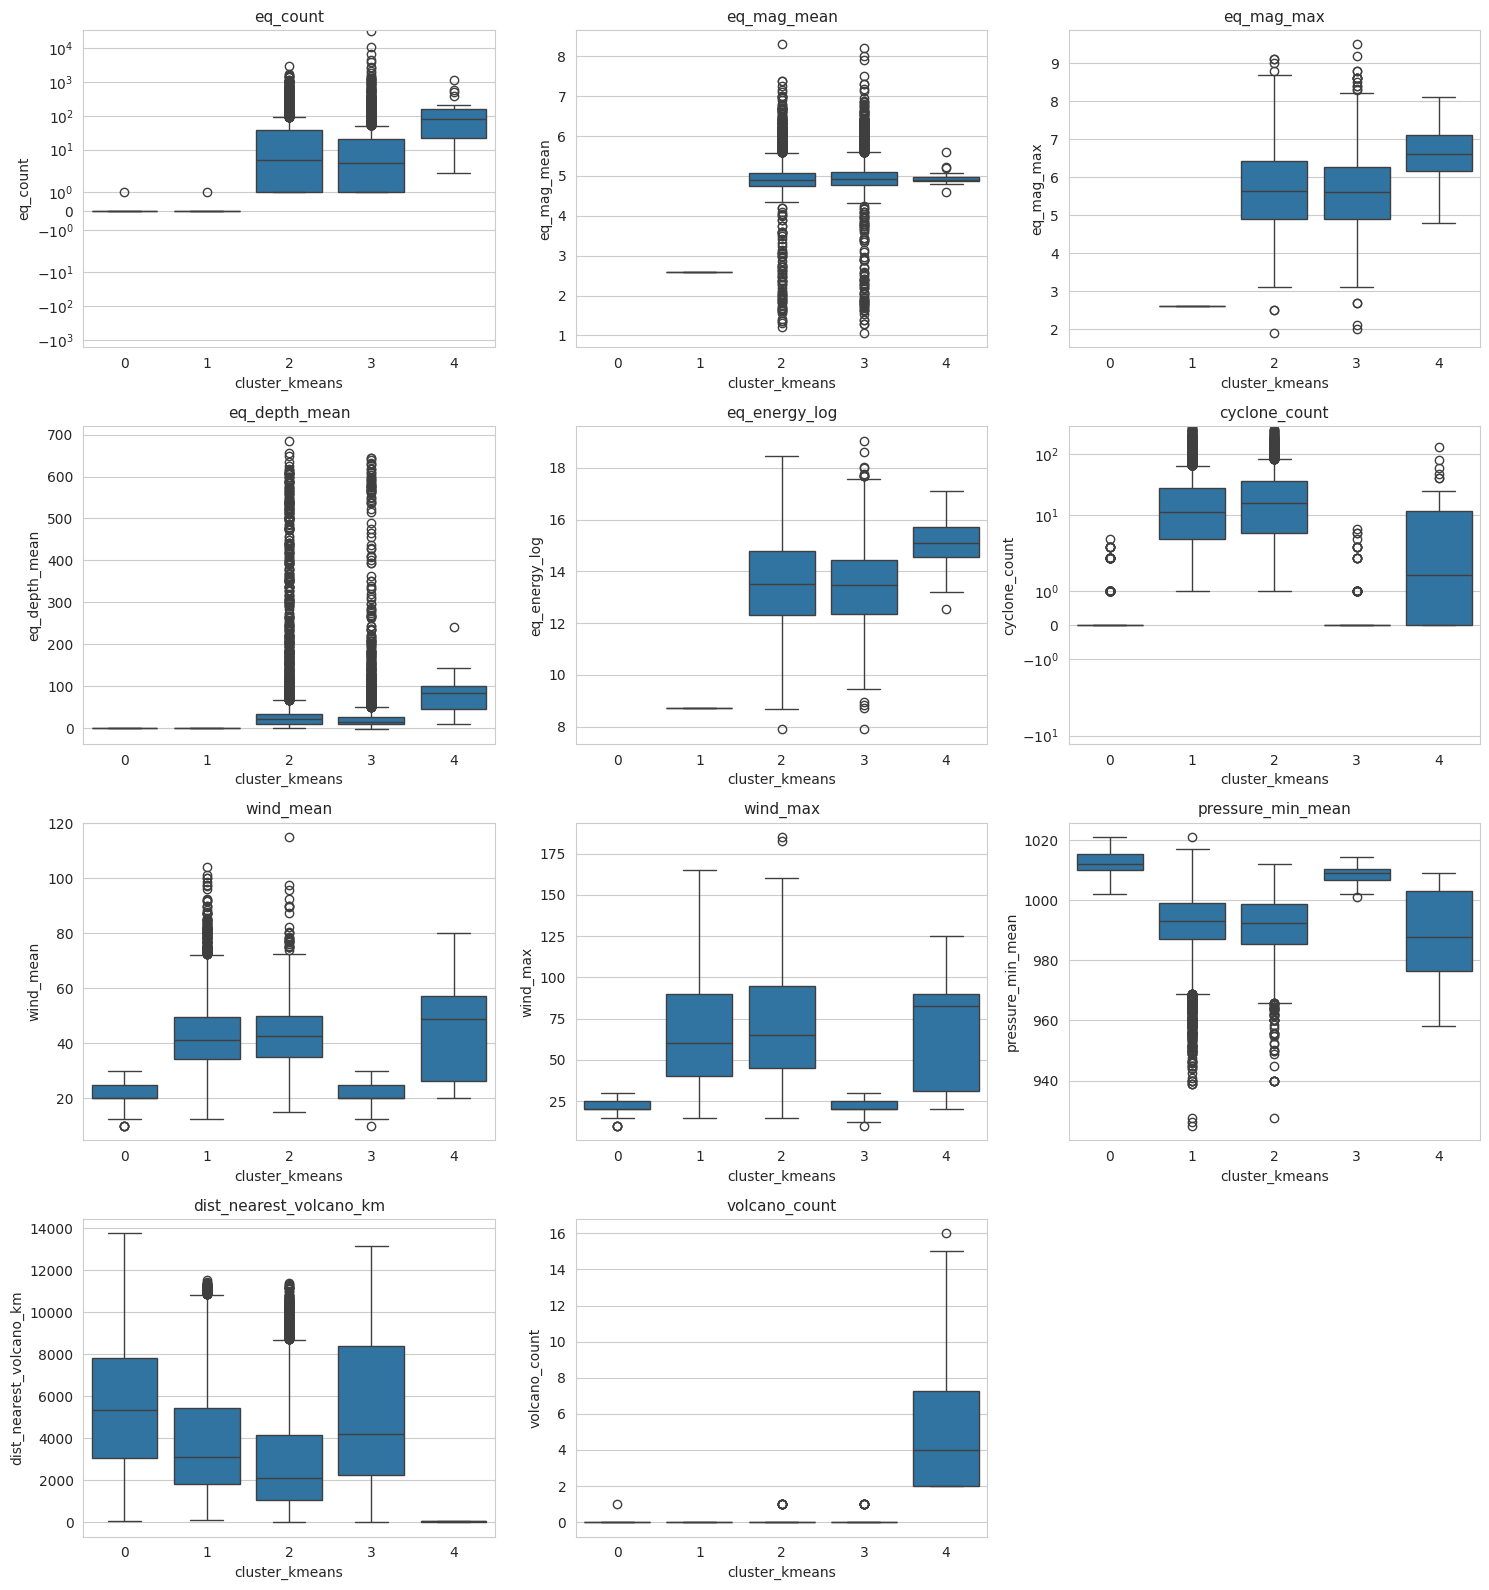

In [8]:
# Detecta y excluye columnas constantes automaticamente (no hay nada que graficar
# en un boxplot si todos los valores son iguales -- y avisa por que, para el reporte).
plot_cols = [c for c in FEATURE_COLS if df[c].nunique() > 1]
dropped_cols = [c for c in FEATURE_COLS if c not in plot_cols]
if dropped_cols:
    print(f"Columnas excluidas por ser constantes (revisar con Persona 3): {dropped_cols}")

# Columnas con distribucion muy sesgada (pocos valores altisimos, muchos ceros)
# se ven mejor en escala logaritmica que en escala lineal.
skewed_cols = ["eq_count", "cyclone_count"]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x="cluster_kmeans", y=col, ax=ax)
    ax.set_title(col, fontsize=11)
    if col in skewed_cols:
        ax.set_yscale("symlog")  # symlog admite el 0, a diferencia de log normal

# Apaga los paneles vacios que quedan si el grid no cierra exacto
for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Traducción a lenguaje de negocio

Aquí es donde el número de cluster deja de ser `cluster_kmeans == 2` y pasa a
ser algo que una aseguradora, un gobierno local o un urbanista pueda usar.

**Metodología (para poder defenderla frente al profesor):** en vez de mirar
la tabla de perfiles y decidir a ojo, calculamos los niveles (Bajo/Medio/Alto)
de cada tipo de riesgo de forma **relativa entre los clusters obtenidos**
(no en términos absolutos de la industria aseguradora, que requeriría
umbrales externos que no tenemos). Esto es una limitación real a mencionar en
la exposición: "Alto" aquí significa "alto respecto a los demás clusters de
este dataset", no un estándar internacional de riesgo sísmico.


In [9]:
# Construimos un ranking objetivo por cluster para CADA tipo de riesgo,
# a partir de cluster_profile (Seccion 6) -- no inventamos las etiquetas,
# las derivamos de los promedios reales.
risk_signals = {
    "riesgo_sismico": ["eq_count", "eq_mag_mean", "eq_energy_log"],
    "riesgo_ciclonico": ["cyclone_count", "wind_mean"],
    "riesgo_volcanico": ["volcano_count"],  # dist_nearest_volcano_km es inverso (menor = mas riesgo)
}

cluster_means = df.groupby("cluster_kmeans")[FEATURE_COLS].mean()
cluster_sizes = df.groupby("cluster_kmeans").size()

# eq_mag_mean/eq_mag_max/eq_depth_mean/eq_energy_log son NaN cuando no hubo
# sismos en la celda (no hay magnitud que promediar). Si un cluster entero
# esta dominado por celdas sin sismos, su promedio de grupo tambien da NaN,
# lo que rompe el ranking. Para el RANKING (no para el perfilado de la
# Seccion 6, que se deja intacto) tratamos "sin sismos" como riesgo sismico
# minimo, no como dato faltante -- es una decision de negocio explicita,
# no un parche silencioso.
cluster_means_for_ranking = cluster_means.fillna(0)

def rank_label(series: pd.Series) -> pd.Series:
    """Rank values ascending and map to Bajo/Medio/Alto in 3 roughly-equal groups."""
    ranks = series.rank(method="first")
    n = len(series)
    labels = pd.cut(ranks, bins=[0, n / 3, 2 * n / 3, n], labels=["Bajo", "Medio", "Alto"])
    return labels

summary_rows = []
for cluster_id in sorted(df["cluster_kmeans"].unique()):
    row = cluster_means.loc[cluster_id]
    summary_rows.append({
        "cluster": cluster_id,
        "n_celdas": int(cluster_sizes[cluster_id]),
        "pct_celdas": round(100 * cluster_sizes[cluster_id] / len(df), 1),
        "eq_count_mean": round(row["eq_count"], 1),
        "eq_mag_mean": round(row["eq_mag_mean"], 2) if pd.notna(row["eq_mag_mean"]) else None,
        "cyclone_count_mean": round(row["cyclone_count"], 1),
        "wind_mean_mean": round(row["wind_mean"], 1),
        "dist_volcano_mean_km": round(row["dist_nearest_volcano_km"], 0),
        "volcano_count_mean": round(row["volcano_count"], 2),
    })

business_table = pd.DataFrame(summary_rows).set_index("cluster")

# Rankeamos usando la version rellenada (cluster_means_for_ranking), no la
# original, para que "sin sismos" cuente como riesgo sismico bajo en vez de NaN.
sismico_score = cluster_means_for_ranking["eq_count"] + cluster_means_for_ranking["eq_mag_mean"]
ciclonico_score = cluster_means_for_ranking["cyclone_count"] + cluster_means_for_ranking["wind_mean"]
volcanico_score = -cluster_means_for_ranking["dist_nearest_volcano_km"]

business_table["nivel_sismico"] = rank_label(sismico_score).values
business_table["nivel_ciclonico"] = rank_label(ciclonico_score).values
business_table["nivel_volcanico"] = rank_label(volcanico_score).values

business_table


,n_celdas,pct_celdas,eq_count_mean,eq_mag_mean,cyclone_count_mean,wind_mean_mean,dist_volcano_mean_km,volcano_count_mean,nivel_sismico,nivel_ciclonico,nivel_volcanico
cluster,,,,,,,,,,,
0,20193,49.1,0.0,NaN,0.0,22.1,5566.0,0.00,Bajo,Medio,Bajo
1,12169,29.6,0.0,2.60,22.4,42.0,3888.0,0.00,Medio,Alto,Medio
2,3704,9.0,52.7,4.93,28.4,42.7,3141.0,0.00,Alto,Alto,Alto
3,5064,12.3,40.5,4.96,0.0,21.5,4980.0,0.00,Medio,Bajo,Medio
4,32,0.1,148.3,4.95,14.9,44.7,42.0,5.62,Alto,Medio,Alto


In [10]:
def build_business_name(row: pd.Series) -> str:
    """Compose a short, human-readable name from the ranked risk levels.
    Purely mechanical -- the RECOMMENDATION column still needs human judgment.
    """
    parts = []
    if row["nivel_sismico"] == "Alto":
        parts.append("sismico alto")
    elif row["nivel_sismico"] == "Bajo":
        parts.append("sismico bajo")
    if row["nivel_ciclonico"] == "Alto":
        parts.append("ciclonico alto")
    elif row["nivel_ciclonico"] == "Bajo":
        parts.append("ciclonico bajo")
    if row["nivel_volcanico"] == "Alto":
        parts.append("cercania volcanica alta")
    return "Riesgo " + ", ".join(parts) if parts else "Riesgo mixto/moderado"


business_table["nombre_negocio"] = business_table.apply(build_business_name, axis=1)

# TODO(Persona 6): la columna de recomendacion SI requiere criterio humano --
# no se puede derivar solo de los numeros. Complétala con tu propio juicio,
# apoyandote en los niveles ya calculados arriba.
business_table["recomendacion"] = ""  # TODO: completar una frase por cluster

business_table[["n_celdas", "pct_celdas", "nivel_sismico", "nivel_ciclonico",
                "nivel_volcanico", "nombre_negocio", "recomendacion"]]


,n_celdas,pct_celdas,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio,recomendacion
cluster,,,,,,,
0,20193,49.1,Bajo,Medio,Bajo,Riesgo sismico bajo,
1,12169,29.6,Medio,Alto,Medio,Riesgo ciclonico alto,
2,3704,9.0,Alto,Alto,Alto,"Riesgo sismico alto, ciclonico alto, cercania ...",
3,5064,12.3,Medio,Bajo,Medio,Riesgo ciclonico bajo,
4,32,0.1,Alto,Medio,Alto,"Riesgo sismico alto, cercania volcanica alta",


## 8. Casos de estudio: Japón, Chile, Venezuela, España

**Metodología:** como todavía no tenemos un join oficial celda→país (eso
requeriría datos administrativos de fronteras, fuera del alcance de esta
sección), aproximamos cada país con un **bounding box** (rectángulo de
lat/lon). Es una simplificación real y se documenta como tal: un bounding box
puede incluir zonas de países vecinos o mar territorial. Para los 4 países
pedidos, el error introducido es aceptable porque no comparten fronteras
próximas entre sí de forma problemática (con la posible excepción de Chile,
donde el rectángulo puede rozar Argentina/Bolivia/Perú en los bordes).

Para cada país: filtramos las celdas dentro del rectángulo, vemos qué
cluster(s) predominan, y lo cruzamos con la tabla de negocio de la Sección 7.


In [11]:
# Bounding boxes aproximados (lat_min, lat_max, lon_min, lon_max).
# Fuente: rangos geograficos estandar de cada pais (Wikipedia / Natural Earth).
COUNTRY_BBOXES = {
    "Japon":     (24.0, 46.0, 122.0, 146.0),
    "Chile":     (-56.0, -17.5, -76.0, -66.0),
    "Venezuela": (0.6, 12.5, -73.5, -59.5),
    "Espana":    (35.9, 43.9, -9.5, 4.4),
}


def filter_country(data: pd.DataFrame, bbox: tuple) -> pd.DataFrame:
    lat_min, lat_max, lon_min, lon_max = bbox
    return data[
        (data["lat"] >= lat_min) & (data["lat"] <= lat_max) &
        (data["lon"] >= lon_min) & (data["lon"] <= lon_max)
    ]


country_summaries = {}
for country, bbox in COUNTRY_BBOXES.items():
    subset = filter_country(df, bbox)
    dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index()
    country_summaries[country] = {"n_celdas": len(subset), "distribucion": dist}
    print(f"{country}: {len(subset)} celdas")

country_summaries


Japon: 503 celdas
Chile: 331 celdas
Venezuela: 172 celdas
Espana: 85 celdas


{'Japon': {'n_celdas': 503,
  'distribucion': cluster_kmeans
  0    0.003976
  1    0.328032
  2    0.658052
  3    0.003976
  4    0.005964
  Name: proportion, dtype: float64},
 'Chile': {'n_celdas': 331,
  'distribucion': cluster_kmeans
  0    0.377644
  3    0.622356
  Name: proportion, dtype: float64},
 'Venezuela': {'n_celdas': 172,
  'distribucion': cluster_kmeans
  0    0.569767
  1    0.029070
  2    0.186047
  3    0.215116
  Name: proportion, dtype: float64},
 'Espana': {'n_celdas': 85,
  'distribucion': cluster_kmeans
  0    0.294118
  1    0.141176
  2    0.094118
  3    0.470588
  Name: proportion, dtype: float64}}

### Caso de estudio: Japón

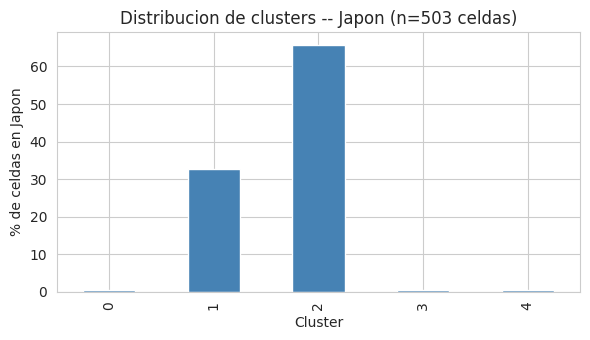

Cluster dominante en Japon: 2 (65.8% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
2,Alto,Alto,Alto,"Riesgo sismico alto, ciclonico alto, cercania ..."


In [12]:
subset = filter_country(df, COUNTRY_BBOXES["Japon"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Japon")
ax.set_title("Distribucion de clusters -- Japon (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Japon: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


### Caso de estudio: Chile

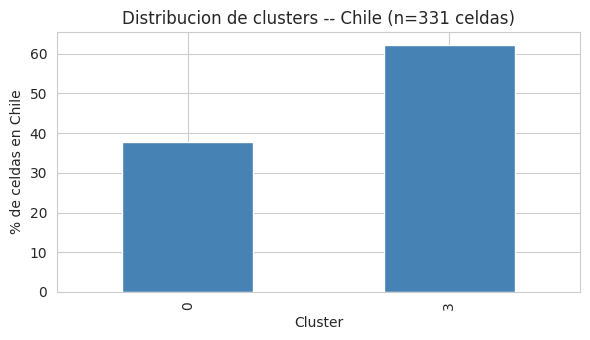

Cluster dominante en Chile: 3 (62.2% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
3,Medio,Bajo,Medio,Riesgo ciclonico bajo


In [13]:
subset = filter_country(df, COUNTRY_BBOXES["Chile"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Chile")
ax.set_title("Distribucion de clusters -- Chile (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Chile: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


### Caso de estudio: Venezuela

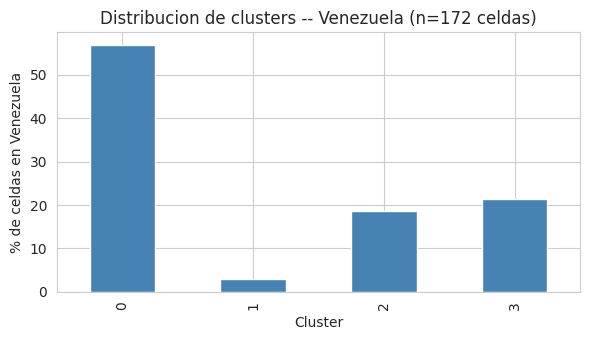

Cluster dominante en Venezuela: 0 (57.0% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
0,Bajo,Medio,Bajo,Riesgo sismico bajo


In [14]:
subset = filter_country(df, COUNTRY_BBOXES["Venezuela"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Venezuela")
ax.set_title("Distribucion de clusters -- Venezuela (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Venezuela: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


### Caso de estudio: España

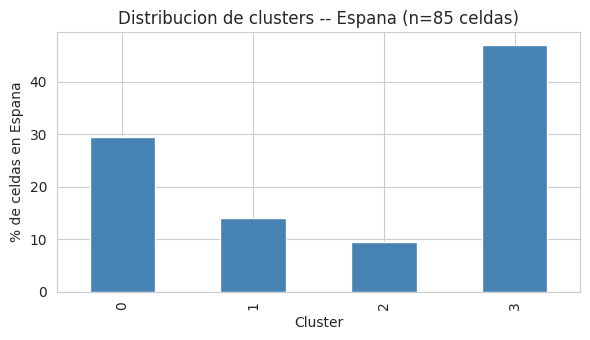

Cluster dominante en Espana: 3 (47.1% de las celdas)
Perfil de negocio de ese cluster:


,nivel_sismico,nivel_ciclonico,nivel_volcanico,nombre_negocio
cluster,,,,
3,Medio,Bajo,Medio,Riesgo ciclonico bajo


In [15]:
subset = filter_country(df, COUNTRY_BBOXES["Espana"])
dist = subset["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(6, 3.5))
dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de celdas en Espana")
ax.set_title("Distribucion de clusters -- Espana (n={} celdas)".format(len(subset)))
plt.tight_layout()
plt.show()

dominant_cluster = dist.idxmax()
print(f"Cluster dominante en Espana: {dominant_cluster} ({dist[dominant_cluster]:.1f}% de las celdas)")
print(f"Perfil de negocio de ese cluster:")
business_table.loc[[dominant_cluster], ["nivel_sismico", "nivel_ciclonico", "nivel_volcanico", "nombre_negocio"]]


## 9. Conclusiones finales

**TODO(Persona 6):** resumen ejecutivo (10-15 líneas) que combine:
- Veredicto de estabilidad (Sección 5).
- Los perfiles de negocio más relevantes (Sección 7).
- Qué implica esto para el producto final (demo / pitch del Dúo A en su rotación).
